# **Analisis Tren Gaji, Level Pengalaman, dan Pola Kerja Profesi Data Science di Pasar Global**

Kelompok 1 :
KHOFIFAH DWI SANNI EL RANDI

Dataset: https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## **Load Dataset**

In [ ]:
df = pd.read_csv('ds_salaries.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## **Cek Dataset**

In [ ]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

Jumlah Baris dan Kolom:
(607, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


## **Statistik Deskriptif**

In [ ]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [ ]:
df.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,607,607,607,607,607,607,607
unique,4,4,50,17,57,50,3
top,SE,FT,Data Scientist,USD,US,US,M
freq,280,588,143,398,332,355,326


## **Preprocessing**

In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Kolom 'Unnamed: 0' berhasil dihapus.")
else:
    print("Tidak terdapat kolom Unnamed.")

Kolom 'Unnamed: 0' berhasil dihapus.


In [ ]:
missing = df.isnull().sum()

print(missing)

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [ ]:
if df.isnull().sum().sum()==0:
    print("Tidak terdapat missing value.")

Tidak terdapat missing value.


In [ ]:
print(df.columns)

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')


In [ ]:
print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 42


In [ ]:
df = df.drop_duplicates()

print("Ukuran dataset setelah menghapus duplikat :")

print(df.shape)

Ukuran dataset setelah menghapus duplikat :
(565, 11)


In [ ]:
df.dtypes

,0
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary,int64
salary_currency,object
salary_in_usd,int64
employee_residence,object
remote_ratio,int64
company_location,object


In [ ]:
for col in df.columns:
    print("="*50)
    print(col)
    print(df[col].unique())

work_year
[2020 2021 2022]
experience_level
['MI' 'SE' 'EN' 'EX']
employment_type
['FT' 'CT' 'PT' 'FL']
job_title
['Data Scientist' 'Machine Learning Scientist' 'Big Data Engineer'
 'Product Data Analyst' 'Machine Learning Engineer' 'Data Analyst'
 'Lead Data Scientist' 'Business Data Analyst' 'Lead Data Engineer'
 'Lead Data Analyst' 'Data Engineer' 'Data Science Consultant'
 'BI Data Analyst' 'Director of Data Science' 'Research Scientist'
 'Machine Learning Manager' 'Data Engineering Manager'
 'Machine Learning Infrastructure Engineer' 'ML Engineer' 'AI Scientist'
 'Computer Vision Engineer' 'Principal Data Scientist'
 'Data Science Manager' 'Head of Data' '3D Computer Vision Researcher'
 'Data Analytics Engineer' 'Applied Data Scientist'
 'Marketing Data Analyst' 'Cloud Data Engineer' 'Financial Data Analyst'
 'Computer Vision Software Engineer' 'Director of Data Engineering'
 'Data Science Engineer' 'Principal Data Engineer'
 'Machine Learning Developer' 'Applied Machine Learning 

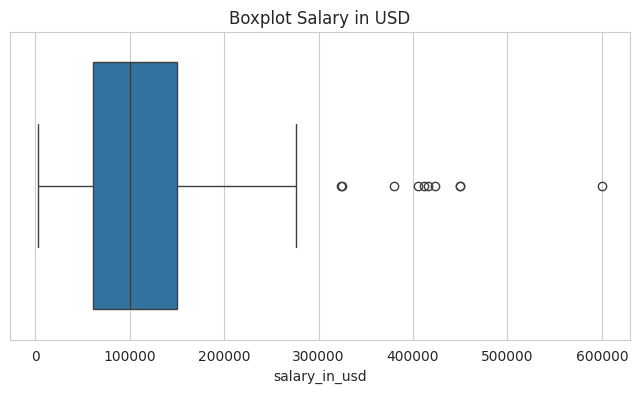

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['salary_in_usd'])

plt.title("Boxplot Salary in USD")

plt.show()

In [ ]:
experience = {
    'EN':'Entry Level',
    'MI':'Mid Level',
    'SE':'Senior Level',
    'EX':'Executive'
}

df['experience_level'] = df['experience_level'].map(experience)

In [ ]:
company = {
    'S':'Small',
    'M':'Medium',
    'L':'Large'
}

df['company_size'] = df['company_size'].map(company)

In [ ]:
employment = {
    'FT':'Full Time',
    'PT':'Part Time',
    'CT':'Contract',
    'FL':'Freelance'
}

df['employment_type'] = df['employment_type'].map(employment)

In [ ]:
remote = {
    0:'Onsite',
    50:'Hybrid',
    100:'Remote'
}

df['work_mode'] = df['remote_ratio'].map(remote)

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,work_mode
0,2020,Mid Level,Full Time,Data Scientist,70000,EUR,79833,DE,0,DE,Large,Onsite
1,2020,Senior Level,Full Time,Machine Learning Scientist,260000,USD,260000,JP,0,JP,Small,Onsite
2,2020,Senior Level,Full Time,Big Data Engineer,85000,GBP,109024,GB,50,GB,Medium,Hybrid
3,2020,Mid Level,Full Time,Product Data Analyst,20000,USD,20000,HN,0,HN,Small,Onsite
4,2020,Senior Level,Full Time,Machine Learning Engineer,150000,USD,150000,US,50,US,Large,Hybrid


In [ ]:
salary_stats = pd.DataFrame({
    "Statistik":[
        "Mean",
        "Median",
        "Standar Deviasi",
        "Minimum",
        "Maximum"
    ],
    "Nilai":[
        df['salary_in_usd'].mean(),
        df['salary_in_usd'].median(),
        df['salary_in_usd'].std(),
        df['salary_in_usd'].min(),
        df['salary_in_usd'].max()
    ]
})

display(salary_stats)

,Statistik,Nilai
0,Mean,110610.343363
1,Median,100000.000000
2,Standar Deviasi,72280.702792
3,Minimum,2859.000000
4,Maximum,600000.000000


## **EDA**

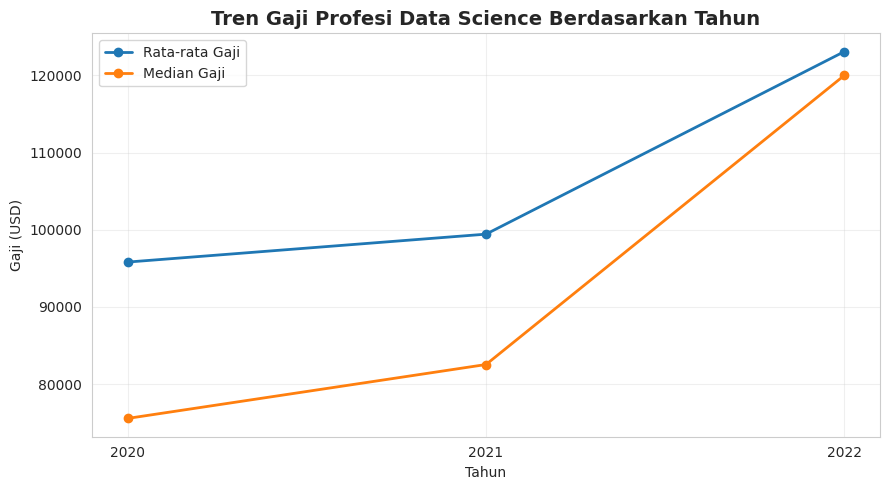

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    salary_by_year["work_year"],
    salary_by_year["mean"],
    marker="o",
    linewidth=2,
    label="Rata-rata Gaji"
)

plt.plot(
    salary_by_year["work_year"],
    salary_by_year["median"],
    marker="o",
    linewidth=2,
    label="Median Gaji"
)

plt.title(
    "Tren Gaji Profesi Data Science Berdasarkan Tahun",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tahun")
plt.ylabel("Gaji (USD)")

plt.xticks(
    salary_by_year["work_year"],
    rotation=0
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

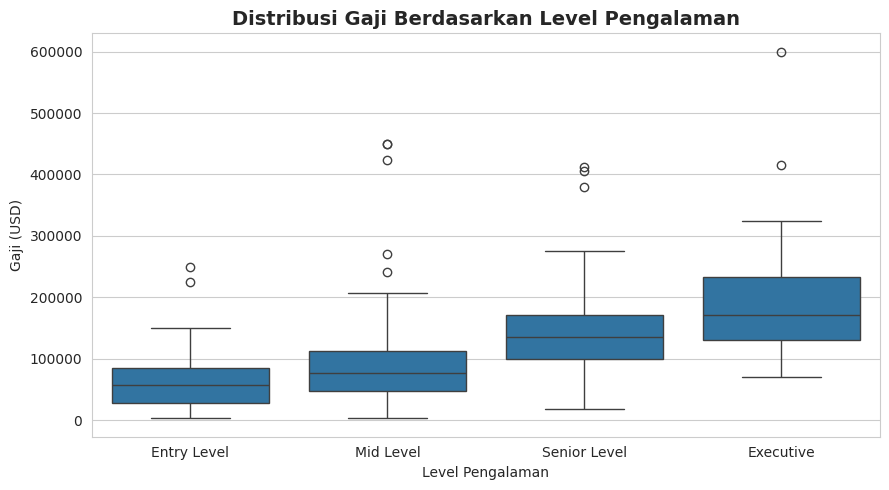

In [ ]:
order_experience = [
    "Entry Level",
    "Mid Level",
    "Senior Level",
    "Executive"
]

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_in_usd",
    order=order_experience
)

plt.title(
    "Distribusi Gaji Berdasarkan Level Pengalaman",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Level Pengalaman")
plt.ylabel("Gaji (USD)")

plt.tight_layout()
plt.show()

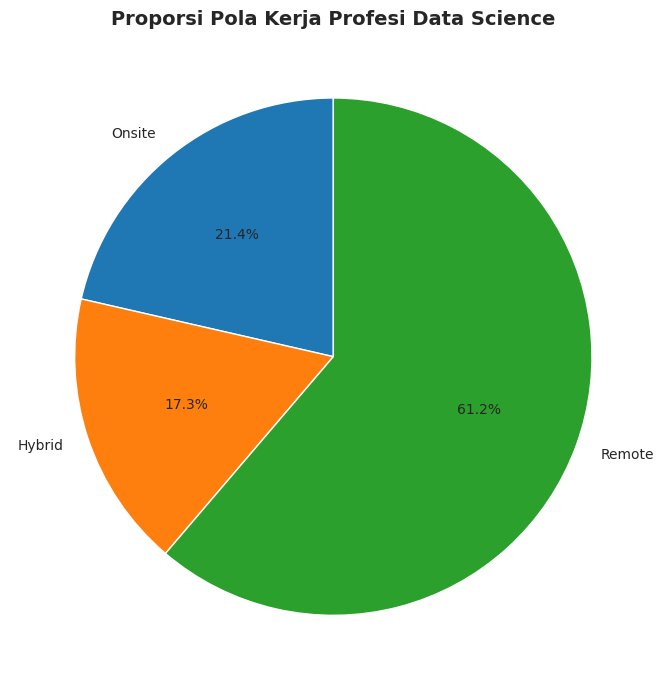

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(
    salary_by_remote["count"],
    labels=salary_by_remote.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Proporsi Pola Kerja Profesi Data Science",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

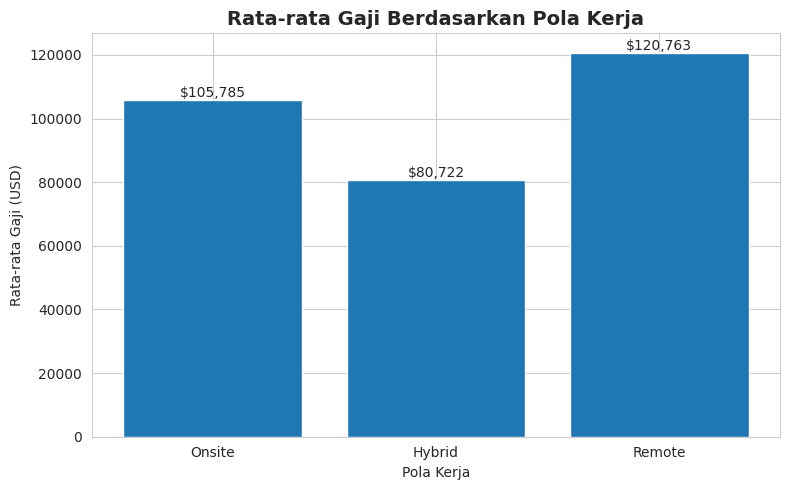

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    salary_by_remote.index,
    salary_by_remote["mean"]
)

plt.title(
    "Rata-rata Gaji Berdasarkan Pola Kerja",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Pola Kerja")
plt.ylabel("Rata-rata Gaji (USD)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

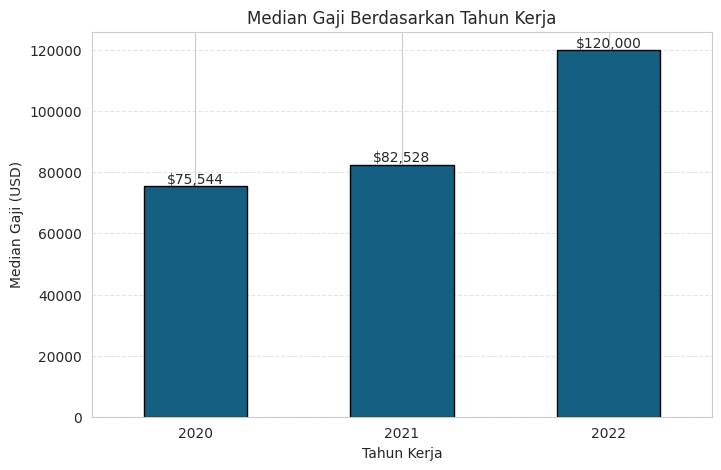

In [ ]:
salary_year = (
    df.groupby('work_year')['salary_in_usd']
      .median()
)

plt.figure(figsize=(8,5))

ax = salary_year.plot(
    kind='bar',
    color='#155F82',
    edgecolor='black'
)

plt.title('Median Gaji Berdasarkan Tahun Kerja')
plt.xlabel('Tahun Kerja')
plt.ylabel('Median Gaji (USD)')

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menampilkan nilai di atas batang
for i, v in enumerate(salary_year):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.show()

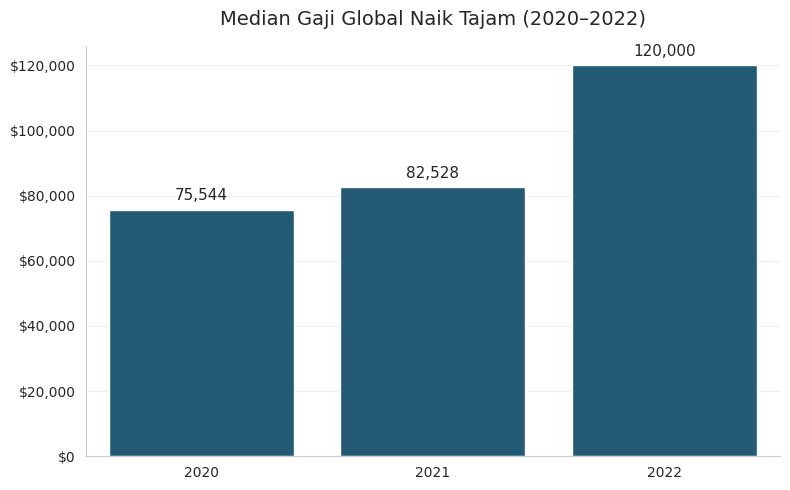

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

salary_year = (
    df.groupby('work_year')['salary_in_usd']
      .median()
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=salary_year,
    x='work_year',
    y='salary_in_usd',
    color='#155F82'
)

# Label nilai
for i, value in enumerate(salary_year['salary_in_usd']):
    ax.text(
        i,
        value + 3000,
        f'{value:,.0f}',
        ha='center',
        fontsize=11
    )

ax.set_title(
    'Median Gaji Global Naik Tajam (2020–2022)',
    fontsize=14,
    pad=15
)

ax.set_xlabel('')
ax.set_ylabel('')

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

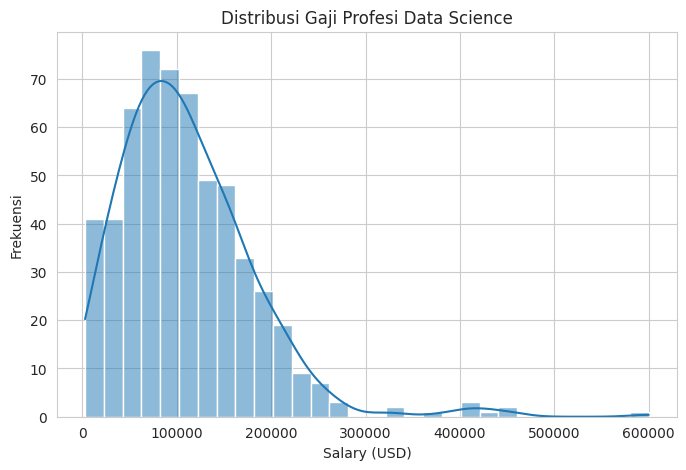

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['salary_in_usd'], bins=30, kde=True)

plt.title('Distribusi Gaji Profesi Data Science')
plt.xlabel('Salary (USD)')
plt.ylabel('Frekuensi')

plt.show()

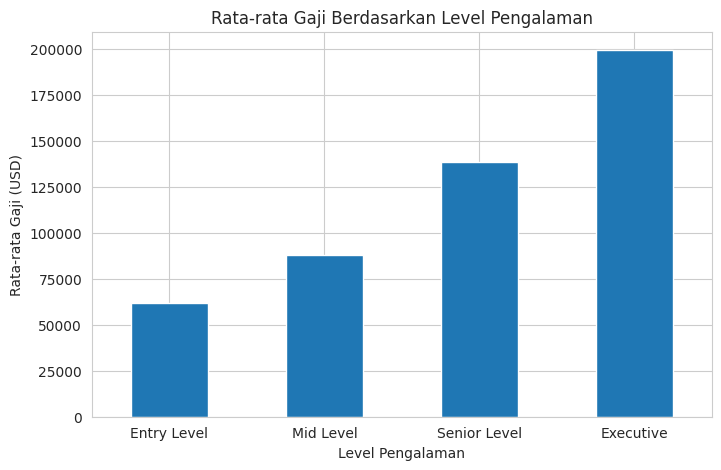

In [ ]:
salary_exp = (
    df.groupby('experience_level')['salary_in_usd']
      .mean()
      .reindex(['Entry Level','Mid Level','Senior Level','Executive'])
)

plt.figure(figsize=(8,5))

salary_exp.plot(kind='bar')

plt.title('Rata-rata Gaji Berdasarkan Level Pengalaman')
plt.xlabel('Level Pengalaman')
plt.ylabel('Rata-rata Gaji (USD)')

plt.xticks(rotation=0)

plt.show()

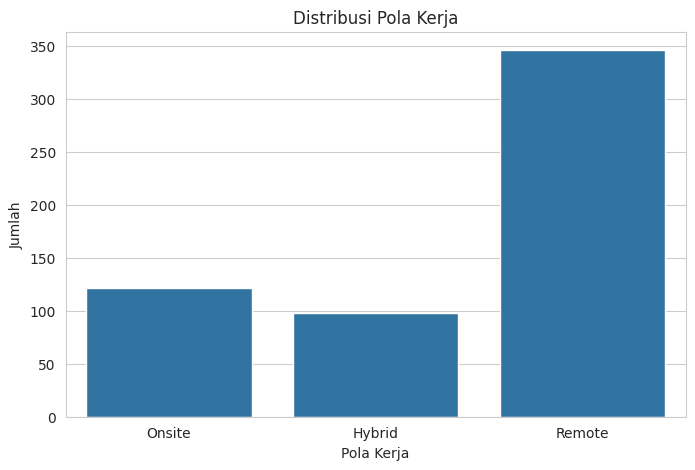

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='work_mode',
    order=['Onsite','Hybrid','Remote']
)

plt.title('Distribusi Pola Kerja')

plt.xlabel('Pola Kerja')

plt.ylabel('Jumlah')

plt.show()

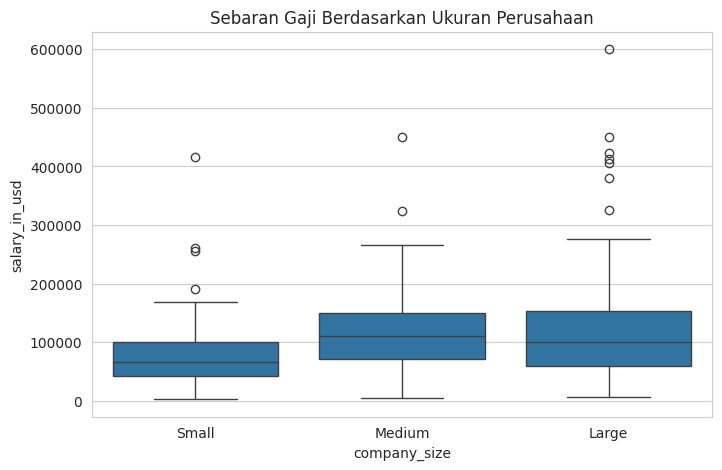

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='company_size',
    y='salary_in_usd',
    order=['Small','Medium','Large']
)

plt.title('Sebaran Gaji Berdasarkan Ukuran Perusahaan')

plt.show()